# Plots

- Evaluations should be performed over:
    - [1...10] seed values per epsilon (over which will be averaged).
    - Epsilons of [0.5, 0.75, 1, 1.5, 2, 3, 4.5, 6.5, 9, 12, 16, 20]

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import scipy
import pandas as pd
from pprint import pprint
from glob import glob
import pickle
from tqdm import tqdm
import os
pd.set_option('display.width', 200)

EPS = [0.5, 0.75, 1, 1.5, 2, 3, 4.5, 6.5, 9, 12, 16, 20]
DATAS = {
    "Facebook": {
        "feature_file": "feature_matrix_50_densest_binary-ish.txt",
        "target_file": "",
        "order": 0,
    },
    "LastFM": {
        "feature_file": "feature_matrix_50_highest_entropy.pkl",
        "target_file": "targets_reduced_5.txt",
        "order": 1,
    },
    "GitHub": {
        "feature_file": "feature_matrix_50_highest_entropy.pkl",
        "target_file": "targets.txt",
        "order": 2,
    },
    "Brightkite": {
        "feature_file": "feature_matrix_top_50.txt",
        "target_file": "",
        "order": 3,
    }
}
METHODS = {
    "ALJ": {
        "directory": "Ahmed16 - ALJ/result/",
        "num_trials": 10,
        "order": 2,
    },
    "CAGMDP": {
        "directory": "CAGMDP, TriCycLe/CAGMDP_result/", # 2020
        "num_trials": 10,
        "order": 5,
    },
    "TriCycLe": {
        "directory": "CAGMDP, TriCycLe/TriCycLe_result/", # 2016
        "num_trials": 10,
        "order": 3,
    },
    "DER": {
        "directory": "Chen14 - DER/result/",
        "num_trials": 10,
        "order": 0,
    },
    "TmF": {
        "directory": "Nguyen15 - TmF/result/",
        "num_trials": 10,
        "order": 1,
    },
    "LDPGen": {
        "directory": "Qin17 - LDPGen/result/",
        "num_trials": 10,
        "order": 4,
    },
    "DPGGAN": {
        "directory": "Yang21 - DPGGAN, DPGVAE/DPGGAN_result/",
        "num_trials": 10,
        "order": 7,
    },
    "DPGVAE": {
        "directory": "Yang21 - DPGGAN, DPGVAE/DPGVAE_result/",
        "num_trials": 10,
        "order": 6,
    },
    "PrivGraph": {
        "directory": "Yuan23 - PrivGraph/result/",
        "num_trials": 10,
        "order": 8,
    },
}
"""
    "PrivDPR": {
        "directory": "Zhang25 - PrivDPR/result/",
        "num_trials": 10,
        "order": 9,
    },
}
"""
COLOURS = plt.rcParams['axes.prop_cycle'].by_key()['color']

font_size = 14
ticks_fontsize = font_size - 2.5
legend_font_size = font_size - 2
title_font_size = font_size + 1
settings = {
    'font.size': font_size,
    'font.family': "serif", 
    "mathtext.fontset": "dejavuserif",  #cm
    'figure.titlesize': title_font_size,
    'figure.autolayout': True,
    'legend.fontsize': legend_font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size - 1,
    'ytick.labelsize': ticks_fontsize,
    'xtick.labelsize': ticks_fontsize,
    'hatch.linewidth': 0.8,
    'xtick.minor.pad': 1,
    'axes.labelpad': 3,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.linewidth': 0.4,
    'grid.alpha': 0.8,
    'axes.axisbelow': True,
    'legend.framealpha': 1,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'legend.handletextpad': 0.2,
    'legend.columnspacing': 0.5,
    'figure.dpi': 800,
    'figure.max_open_warning': 0,
    'legend.facecolor': 'white',
    'lines.linewidth': 1,
    'errorbar.capsize': 3,  
    'lines.markeredgewidth': 0.5, 
    'lines.markersize': 3,
    'axes.formatter.limits':  [-3, 3],
}
plt.rcParams.update(settings)

TITLE_IDS = {
    "Degree Distribution Error": "(a)",
    "Clustering Coefficient Distribution Error": "(b)",
    "Betweenness Centrality Distribution Error": "(c)",
    "Closeness Centrality Distribution Error": "(d)",
    "Density Error": "(e)",
    "Harmonic Diameter Error": "(f)",
    "Assortativity Error": "(g)",
    "Modularity Error": "(h)",
    "Transitivity Error": "(i)",
}

In [40]:
def reconstruction_results():
    methods = ["DER", "TmF", "TriCycLe", "LDPGen", "CAGMDP", "DPGVAE", "DPGGAN", "PrivGraph"]
    EPS = [1, 3, 9]
    plot_size = 3
    n_cols = 4
    with open("./GRAND/results_reconstruction.pkl", 'rb') as f:
        d = pickle.load(f)
    with open("./GRAND/results_non_reconstruction.pkl", 'rb') as f:
        b = pickle.load(f)
    plot = [None, None]
    fig, axes = plt.subplots(2, n_cols, figsize=(plot_size * n_cols - 2, plot_size * 2 - 1), sharey=True)
    plot[0] = fig; plot[1] = axes.flatten()
    table = {'epsilon': EPS}
    for i, method in enumerate(methods):
        y = []
        for eps in EPS:
            y.append(b[method][eps])
        plot[1][i].plot(EPS, y, label="Private Graph", marker='o')
        table[method + " Private Graph"] = y
        y = []
        for eps in EPS:
            y.append(d[method][eps])
        plot[1][i].plot(EPS, y, label="Reconstruction", marker='o')
        table[method + " Reconstruction"] = y
        
        plot[1][i].set_title(method)
        plot[1][i].set_xscale("log", base=np.e)
        plot[1][i].set_xlabel(r"Privacy Budget ($\epsilon$)")
        plot[1][i].set_ylabel("RAE" + r" ($\%$)")
        plot[1][i].set_xlim((min(EPS),max(EPS)))
        plot[1][i].set_ylim((0, 200))
        plot[1][i].set_xticks(EPS)
        plot[1][i].set_xticklabels(EPS)
        plot[1][i].grid(True, which='both', linewidth=0.4, alpha=0.8, linestyle="--", zorder=0)
    plot[1][-1].legend(frameon=False)
    plot[0].tight_layout(pad=0.25,h_pad=0, w_pad=0.4)
    plot[0].savefig(f"./reconstruction_plot.pdf")
    df = pd.DataFrame(table).T
    df.columns = [f"epsilon={x}" for x in df.iloc[0]]
    df = df[1:]
    df.to_csv(f'./reconstruction.csv')
        
    
def deanonymisation_results():
    metrics = ["Edge Correctness", "Symmetric Substructure Score"]
    methods = ["PrivCom", "PrivDPR"]
    EPS = [1, 3, 9]
    plot_size = 3
    n_cols = 2
    with open("./Pedarsani/results.pkl", 'rb') as f:
        d = pickle.load(f)
    plot = plt.subplots(1, n_cols, figsize=(plot_size * n_cols, plot_size))
    for i, metric in enumerate(metrics):
        table = {'epsilon': EPS}
        for method in methods:
            y = []
            for eps in EPS:
                y.append(d[method][eps][metric])
            plot[1][i].plot(EPS, y, label=method, marker='o')
            table[method] = y
        metric_label = metric.replace("Symmetric", "Sym.").replace("Score", "")
        plot[1][i].set_title(metric_label)
        plot[1][i].set_xscale("log", base=np.e)
        plot[1][i].set_xlabel(r"Privacy Budget ($\epsilon$)")
        plot[1][i].set_ylabel(metric_label + r" ($\%$)")
        plot[1][i].set_ylim(bottom=0)
        plot[1][i].set_xlim((min(EPS),max(EPS)))
        plot[1][i].set_xticks(EPS)
        plot[1][i].set_xticklabels(EPS)
        plot[1][i].legend()
        plot[1][i].grid(True, which='both', linewidth=0.4, alpha=0.8, linestyle="--", zorder=0)
        df = pd.DataFrame(table).T
        df.columns = [f"epsilon={x}" for x in df.iloc[0]]
        df = df[1:]
        df.to_csv(f'./deanonymisation_{metric}.csv')
    plot[0].tight_layout(pad=0.25,h_pad=0, w_pad=0.4)
    plot[0].savefig(f"./deanonymisation_plot.pdf")


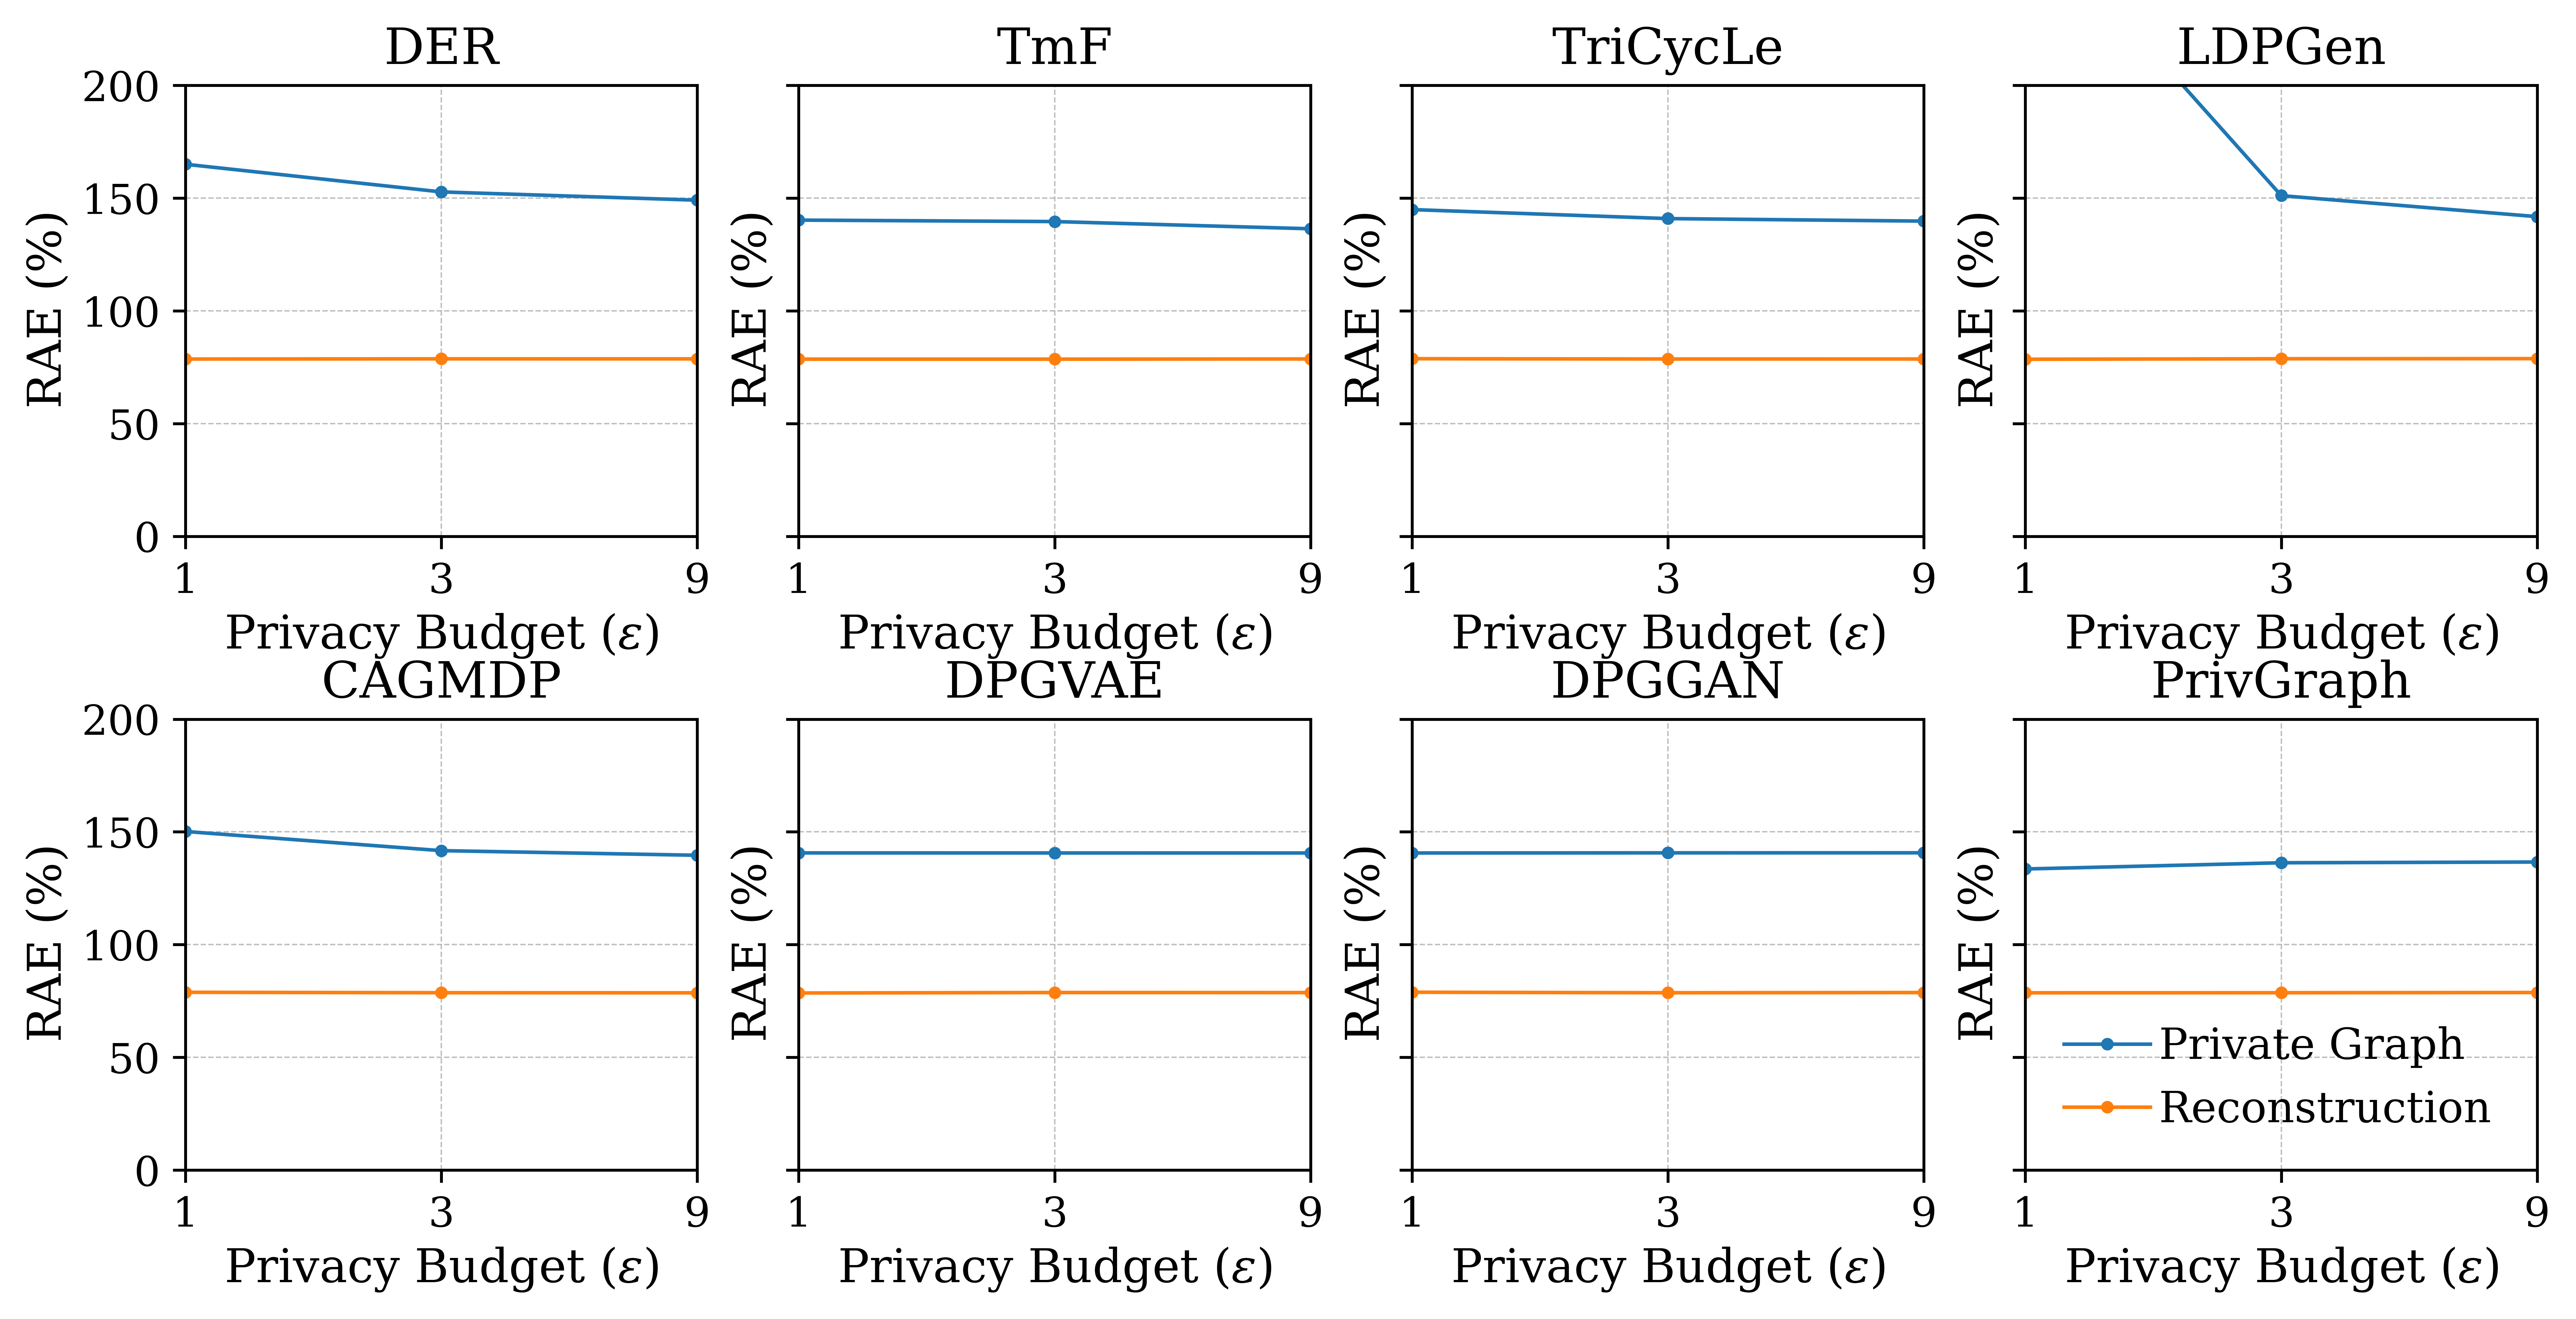

In [41]:
deanonymisation_results()
reconstruction_results()